In [10]:
# Import de libs

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuração para gráficos
sns.set_theme(style="whitegrid")

#Ignorar avisos
import warnings
warnings.filterwarnings('ignore')

#Definindo diretório
caminho = os.getcwd()

In [11]:
print(caminho)

c:\Users\pmoda\Desktop\Estudo


In [12]:
df_teste = pd.read_csv(os.path.join(caminho, 'test.csv'), sep=',')
df_treino = pd.read_csv(os.path.join(caminho,'train.csv'), sep=',')


In [19]:
#Quantidade de linhas e colunas de cada dataset:
print(f"Quantidade de linhas do dataset de treino: {df_treino.shape[0]}")
print(f"Quantidade de colunas do dataset de treino: {df_treino.shape[1]}")

Quantidade de linhas do dataset de treino: 1460
Quantidade de colunas do dataset de treino: 81


In [23]:
#Contagem e separação das colunas por tipo de dado.
colunas_categorias = df_treino.select_dtypes(include=['object']).columns
colunas_numericas = df_treino.select_dtypes(include=[np.number]).columns

print(f"Total de variáveis: {df_treino.shape[1]}")
print(f"Total de variáveis categóricas: {len(colunas_categorias)}")
print(f"Total de variáveis numéricas: {len(colunas_numericas)}")

Total de variáveis: 81
Total de variáveis categóricas: 43
Total de variáveis numéricas: 38


In [35]:
sale_price = df_treino['SalePrice']

metricas = {
    'Métrica': [
        'Média', 
        'Mediana', 
        'Desvio Padrão', 
        'Mínimo', 
        '1º Quartil', 
        '3º Quartil', 
        'Máximo', 
        'Assimetria', 
        'Curtose',
    ],
    'Valor': [
    f"${sale_price.mean():,.2f}",
    f"${sale_price.median():,.2f}",
    f"${sale_price.std():,.2f}",
    f"${sale_price.min():,.2f}",
    f"${sale_price.quantile(0.25):,.2f}",
    f"${sale_price.quantile(0.75):,.2f}",
    f"${sale_price.max():,.2f}",
    f"{sale_price.skew():,.2f}",
    f"{sale_price.kurt():.2f}"
    ]

}

In [36]:
df_resumo_estatistico = pd.DataFrame(metricas)
display(df_resumo_estatistico)

,Métrica,Valor
0,Média,"$180,921.20"
1,Mediana,"$163,000.00"
2,Desvio Padrão,"$79,442.50"
3,Mínimo,"$34,900.00"
4,1º Quartil,"$129,975.00"
5,3º Quartil,"$214,000.00"
6,Máximo,"$755,000.00"
7,Assimetria,1.88
8,Curtose,6.54


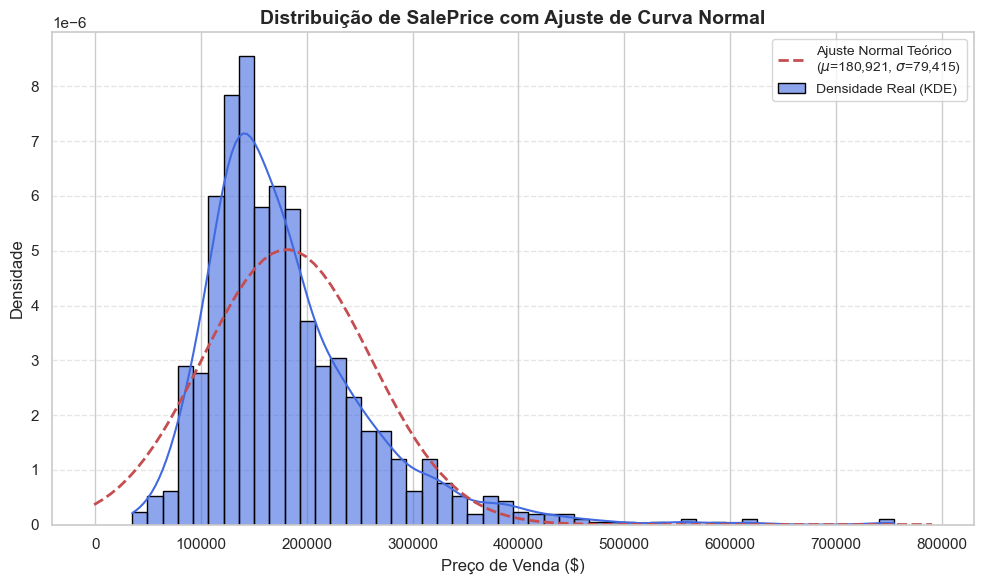

In [37]:
# Configuração da figura
plt.figure(figsize=(10, 6))

# Histograma com estimativa de densidade de Kernel (KDE real)
sns.histplot(
    df_treino['SalePrice'], 
    kde=True, 
    stat="density", 
    color='royalblue', 
    bins=50, 
    edgecolor='black', 
    alpha=0.6, 
    label='Densidade Real (KDE)'
)

#Ajuste e plotagem da Curva Normal Teórica

mu, std = stats.norm.fit(df_treino['SalePrice']) #ajuste normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(
    x, p, 'r--', linewidth=2, 
    label=f'Ajuste Normal Teórico\n($\mu$={mu:,.0f}, $\sigma$={std:,.0f})'
)

# Formatação e Títulos
plt.title('Distribuição de SalePrice com Ajuste de Curva Normal', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda ($)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

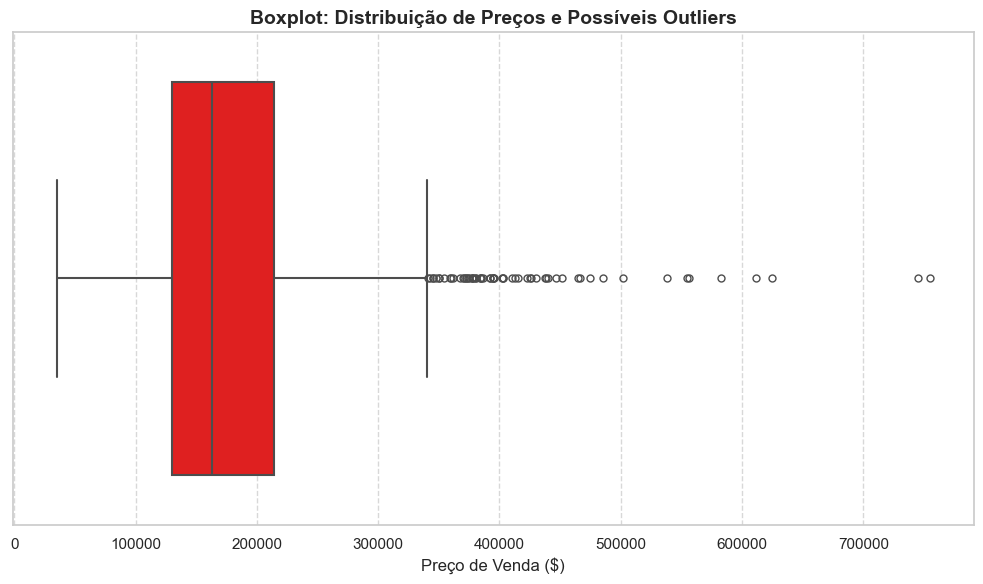

Limite inferior: $3,937.50
Limite superior: $340,037.50

Possíveis outliers inferiores: 0
Possíveis outliers superiores: 61


In [38]:
plt.figure(figsize=(10, 6))

# Geração do Boxplot
sns.boxplot(
    x=df_treino['SalePrice'],
    color='red',
    fliersize=5,
    linewidth=1.5
)

plt.title(
    'Boxplot: Distribuição de Preços e Possíveis Outliers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Preço de Venda ($)', fontsize=12)

plt.grid(
    axis='x',
    alpha=0.75,
    linestyle='--'
)

plt.tight_layout()
plt.show()


# ==========================
# Cálculo dos limites do IQR
# ==========================

Q1 = df_treino['SalePrice'].quantile(0.25)
Q3 = df_treino['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# Possíveis outliers
outliers_inferiores = df_treino[
    df_treino['SalePrice'] < limite_inferior
]

outliers_superiores = df_treino[
    df_treino['SalePrice'] > limite_superior
]


print(f"Limite inferior: ${limite_inferior:,.2f}")
print(f"Limite superior: ${limite_superior:,.2f}")

print(f"\nPossíveis outliers inferiores: {len(outliers_inferiores)}")
print(f"Possíveis outliers superiores: {len(outliers_superiores)}")